# Barrier Options: Interactive Analysis & Visualizations

**Product Type:** Path-Dependent European Exotic Option  
**Purpose:** Interactive exploration of barrier option pricing, In-Out parity, and hedging challenges

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Payoff Diagrams](#2-payoff-diagrams)
3. [Price Surfaces](#3-price-surfaces)
4. [In-Out Parity](#4-in-out-parity)
5. [Greeks Analysis](#5-greeks-analysis)
6. [Discrete vs Continuous Monitoring](#6-discrete-vs-continuous-monitoring)
7. [Sample Paths Visualization](#7-sample-paths-visualization)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# Color scheme
COLORS = {
    'vanilla': '#34495e',
    'knock_out': '#e74c3c',
    'knock_in': '#2ecc71',
    'barrier': '#9b59b6',
    'path_alive': '#3498db',
    'path_dead': '#95a5a6',
}

In [2]:
# Base parameters
BASE_PARAMS = {
    'S0': 100.0,
    'K': 100.0,
    'H': 90.0,      # Down barrier
    'T': 1.0,
    'r': 0.05,
    'q': 0.02,
    'sigma': 0.20,
}

# save figures
SAVE_FIGURES = False

print("Base Parameters:")
print("-" * 40)
for key, value in BASE_PARAMS.items():
    print(f"{key:12s}: {value}")

Base Parameters:
----------------------------------------
S0          : 100.0
K           : 100.0
H           : 90.0
T           : 1.0
r           : 0.05
q           : 0.02
sigma       : 0.2


## Pricing Functions

In [3]:
def bs_call(S, K, T, r, q, sigma):
    """Black-Scholes vanilla call."""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, T, r, q, sigma):
    """Black-Scholes vanilla put."""
    if T <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

In [4]:
def barrier_mc(S0, K, H, T, r, q, sigma, n_paths=100000, n_steps=252,
               barrier_type='down', knock_type='out', option_type='call', seed=42):
    """
    Monte Carlo pricer for barrier options (discrete monitoring).
    
    Parameters
    ----------
    barrier_type : str
        'down' or 'up'
    knock_type : str
        'out' (knock-out) or 'in' (knock-in)
    option_type : str
        'call' or 'put'
    """
    np.random.seed(seed)
    
    dt = T / n_steps
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Generate paths
    Z = np.random.standard_normal((n_paths, n_steps))
    log_returns = drift + diffusion * Z
    log_paths = np.cumsum(log_returns, axis=1)
    paths = S0 * np.exp(np.column_stack([np.zeros(n_paths), log_paths]))
    
    # Check barrier condition
    if barrier_type == 'down':
        hit_barrier = np.min(paths, axis=1) <= H
    else:  # up
        hit_barrier = np.max(paths, axis=1) >= H
    
    # Determine which paths are "alive"
    if knock_type == 'out':
        alive = ~hit_barrier  # Alive if barrier NOT hit
    else:  # in
        alive = hit_barrier   # Alive if barrier IS hit
    
    # Compute payoffs
    S_T = paths[:, -1]
    if option_type == 'call':
        payoffs = np.maximum(S_T - K, 0)
    else:
        payoffs = np.maximum(K - S_T, 0)
    
    # Apply barrier condition
    payoffs = payoffs * alive
    
    price = np.exp(-r * T) * np.mean(payoffs)
    se = np.exp(-r * T) * np.std(payoffs) / np.sqrt(n_paths)
    
    return price, se, paths, hit_barrier

## 2. Payoff Diagrams

Barrier options have conditional payoffs based on path history.

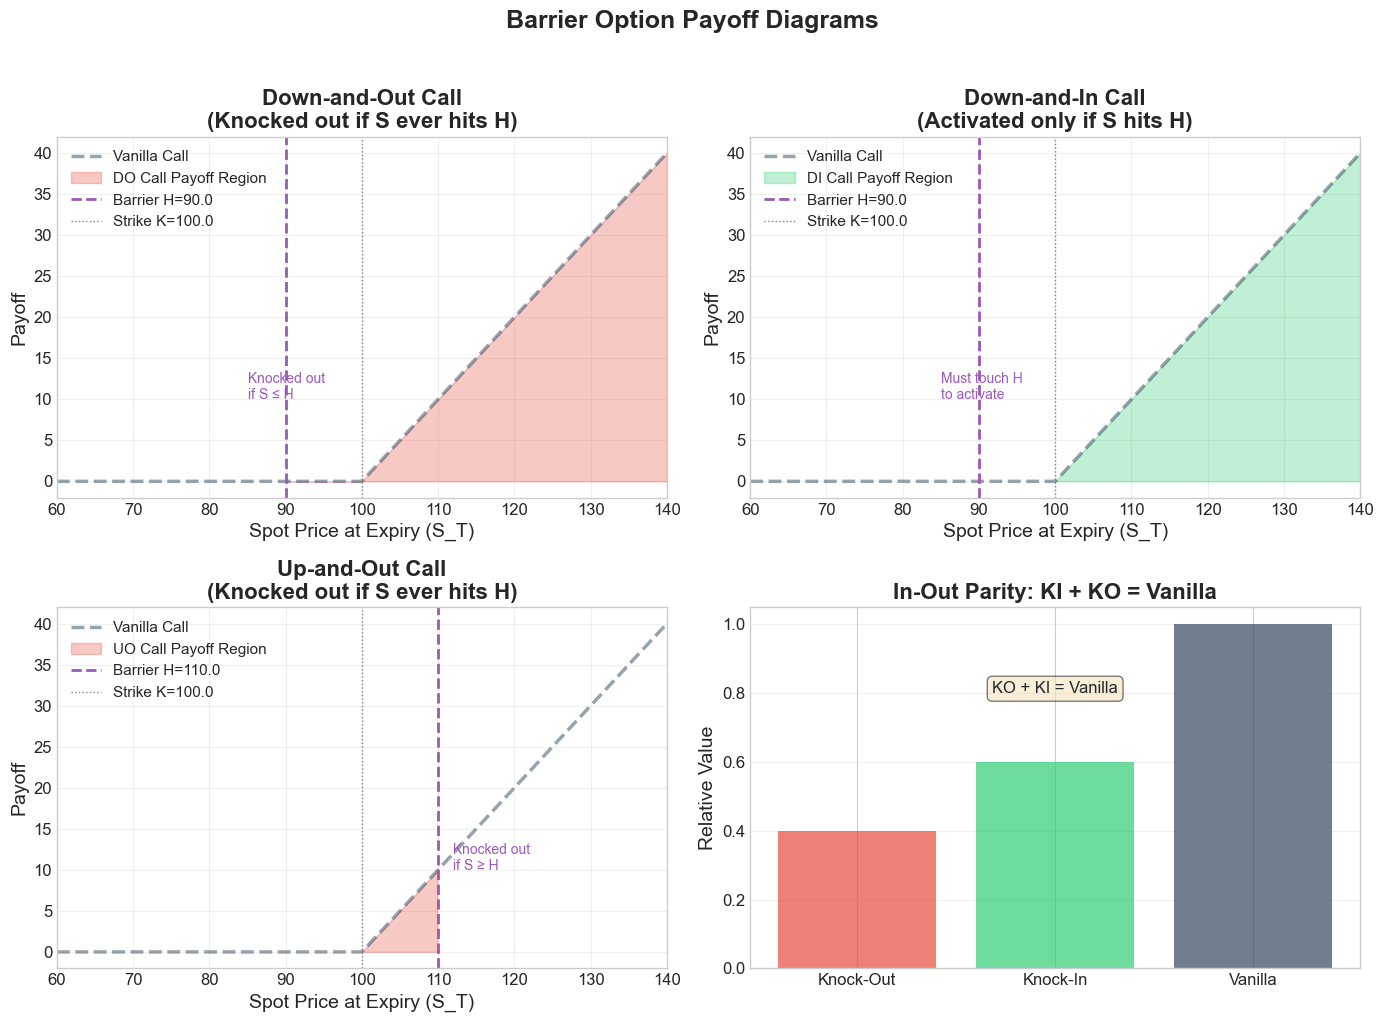

In [5]:
def plot_barrier_payoff_diagrams(save_fig: bool = False):
    """
    Plot payoff diagrams showing barrier option conditional payoffs.
    """
    K = BASE_PARAMS['K']
    H = BASE_PARAMS['H']  # Down barrier
    H_up = 110.0  # Up barrier for comparison
    
    spots = np.linspace(60, 140, 500)
    
    # Vanilla payoffs
    call_payoff = np.maximum(spots - K, 0)
    put_payoff = np.maximum(K - spots, 0)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Down-and-Out Call
    ax = axes[0, 0]
    # If barrier was hit, payoff is 0; otherwise vanilla
    ax.plot(spots, call_payoff, color=COLORS['vanilla'], linewidth=2.5, 
            linestyle='--', alpha=0.5, label='Vanilla Call')
    # The barrier option pays ONLY if spot stayed above H
    ax.fill_between(spots, 0, call_payoff, where=(spots > H), 
                    alpha=0.3, color=COLORS['knock_out'], label='DO Call Payoff Region')
    ax.axvline(x=H, color=COLORS['barrier'], linewidth=2, linestyle='--', label=f'Barrier H={H}')
    ax.axvline(x=K, color='gray', linewidth=1, linestyle=':', label=f'Strike K={K}')
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Down-and-Out Call\n(Knocked out if S ever hits H)', fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(60, 140)
    ax.annotate('Knocked out\nif S ≤ H', xy=(H-5, 10), fontsize=10, color=COLORS['barrier'])
    
    # Down-and-In Call
    ax = axes[0, 1]
    ax.plot(spots, call_payoff, color=COLORS['vanilla'], linewidth=2.5, 
            linestyle='--', alpha=0.5, label='Vanilla Call')
    ax.fill_between(spots, 0, call_payoff, where=(spots > K), 
                    alpha=0.3, color=COLORS['knock_in'], label='DI Call Payoff Region')
    ax.axvline(x=H, color=COLORS['barrier'], linewidth=2, linestyle='--', label=f'Barrier H={H}')
    ax.axvline(x=K, color='gray', linewidth=1, linestyle=':', label=f'Strike K={K}')
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Down-and-In Call\n(Activated only if S hits H)', fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(60, 140)
    ax.annotate('Must touch H\nto activate', xy=(H-5, 10), fontsize=10, color=COLORS['barrier'])
    
    # Up-and-Out Call
    ax = axes[1, 0]
    ax.plot(spots, call_payoff, color=COLORS['vanilla'], linewidth=2.5, 
            linestyle='--', alpha=0.5, label='Vanilla Call')
    # Up-and-out: payoff capped if barrier touched
    ax.fill_between(spots, 0, call_payoff, where=(spots < H_up) & (spots > K), 
                    alpha=0.3, color=COLORS['knock_out'], label='UO Call Payoff Region')
    ax.axvline(x=H_up, color=COLORS['barrier'], linewidth=2, linestyle='--', label=f'Barrier H={H_up}')
    ax.axvline(x=K, color='gray', linewidth=1, linestyle=':', label=f'Strike K={K}')
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Up-and-Out Call\n(Knocked out if S ever hits H)', fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(60, 140)
    ax.annotate('Knocked out\nif S ≥ H', xy=(H_up+2, 10), fontsize=10, color=COLORS['barrier'])
    
    # In-Out Parity Illustration
    ax = axes[1, 1]
    ax.bar(['Knock-Out', 'Knock-In', 'Vanilla'], [0.4, 0.6, 1.0], 
           color=[COLORS['knock_out'], COLORS['knock_in'], COLORS['vanilla']], alpha=0.7)
    ax.set_ylabel('Relative Value')
    ax.set_title('In-Out Parity: KI + KO = Vanilla', fontweight='bold')
    ax.annotate('KO + KI = Vanilla', xy=(1, 0.8), fontsize=12, ha='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Barrier Option Payoff Diagrams', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_fig:    
        plt.savefig('barrier_payoff_diagrams.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_barrier_payoff_diagrams(save_fig=SAVE_FIGURES)

## 3. Price Surfaces

Computing barrier option prices (MC)...
Done!


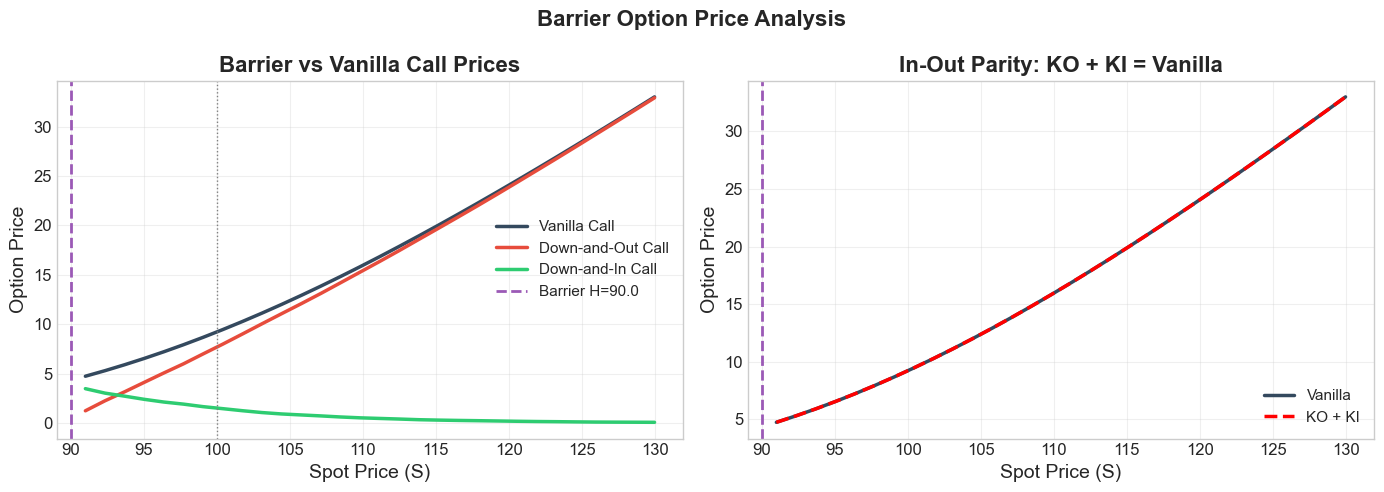

In [6]:
def plot_barrier_price_vs_spot(save_fig: bool = False):
    """
    Plot barrier option prices vs spot, comparing to vanilla.
    """
    K = BASE_PARAMS['K']
    H = BASE_PARAMS['H']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(H + 1, 130, 30)  # Start above barrier
    
    vanilla_prices = [bs_call(S, K, T, r, q, sigma) for S in spots]
    
    print("Computing barrier option prices (MC)...")
    ko_prices = []
    ki_prices = []
    for S in spots:
        ko_price, _, _, _ = barrier_mc(S, K, H, T, r, q, sigma, n_paths=30000, 
                                       barrier_type='down', knock_type='out')
        ko_prices.append(ko_price)
        ki_prices.append(vanilla_prices[len(ko_prices)-1] - ko_price)  # Using parity
    print("Done!")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Price comparison
    ax = axes[0]
    ax.plot(spots, vanilla_prices, color=COLORS['vanilla'], linewidth=2.5, label='Vanilla Call')
    ax.plot(spots, ko_prices, color=COLORS['knock_out'], linewidth=2.5, label='Down-and-Out Call')
    ax.plot(spots, ki_prices, color=COLORS['knock_in'], linewidth=2.5, label='Down-and-In Call')
    ax.axvline(x=H, color=COLORS['barrier'], linewidth=2, linestyle='--', label=f'Barrier H={H}')
    ax.axvline(x=K, color='gray', linewidth=1, linestyle=':')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Option Price')
    ax.set_title('Barrier vs Vanilla Call Prices', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # In-Out Parity verification
    ax = axes[1]
    parity_sum = np.array(ko_prices) + np.array(ki_prices)
    ax.plot(spots, vanilla_prices, color=COLORS['vanilla'], linewidth=2.5, label='Vanilla')
    ax.plot(spots, parity_sum, color='red', linewidth=2.5, linestyle='--', label='KO + KI')
    ax.axvline(x=H, color=COLORS['barrier'], linewidth=2, linestyle='--')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Option Price')
    ax.set_title('In-Out Parity: KO + KI = Vanilla', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Barrier Option Price Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('barrier_price_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_barrier_price_vs_spot(save_fig=SAVE_FIGURES)

Computing prices across barrier levels...
Done!


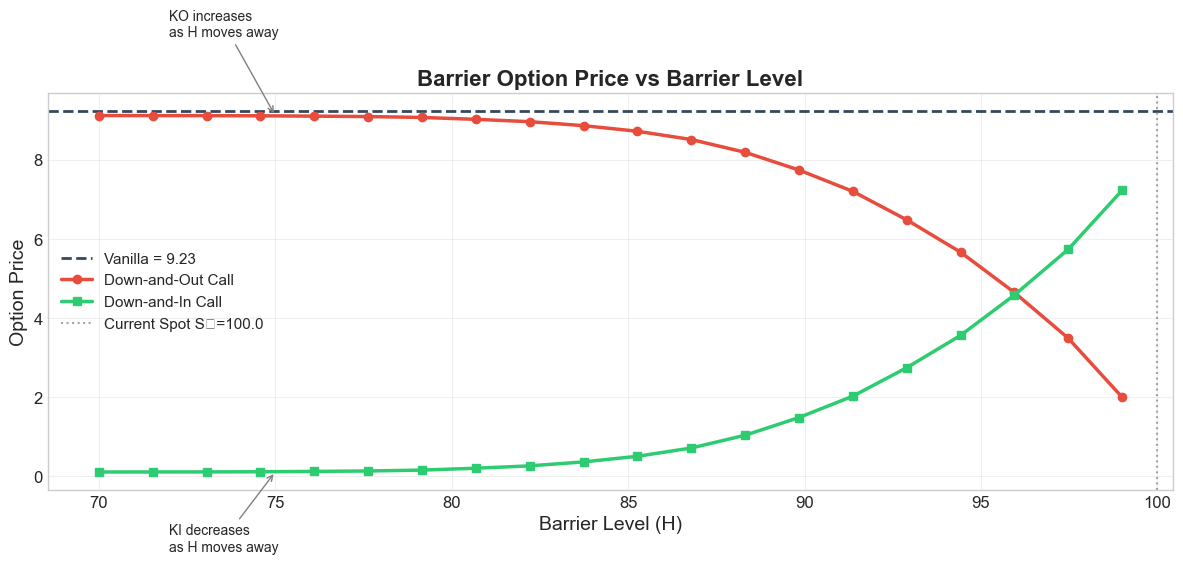

In [7]:
def plot_price_vs_barrier(save_fig: bool = False):
    """
    Plot how option price changes with barrier level.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    barriers = np.linspace(70, 99, 20)  # Down barriers
    
    vanilla_price = bs_call(S0, K, T, r, q, sigma)
    
    print("Computing prices across barrier levels...")
    ko_prices = []
    ki_prices = []
    for H in barriers:
        ko_price, _, _, _ = barrier_mc(S0, K, H, T, r, q, sigma, n_paths=30000, 
                                       barrier_type='down', knock_type='out')
        ko_prices.append(ko_price)
        ki_prices.append(vanilla_price - ko_price)
    print("Done!")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.axhline(y=vanilla_price, color=COLORS['vanilla'], linewidth=2, linestyle='--', 
               label=f'Vanilla = {vanilla_price:.2f}')
    ax.plot(barriers, ko_prices, 'o-', color=COLORS['knock_out'], linewidth=2.5, 
            markersize=6, label='Down-and-Out Call')
    ax.plot(barriers, ki_prices, 's-', color=COLORS['knock_in'], linewidth=2.5, 
            markersize=6, label='Down-and-In Call')
    
    ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.7, label=f'Current Spot S₀={S0}')
    ax.set_xlabel('Barrier Level (H)')
    ax.set_ylabel('Option Price')
    ax.set_title('Barrier Option Price vs Barrier Level', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add annotations
    ax.annotate('KO increases\nas H moves away', xy=(75, ko_prices[2]), xytext=(72, ko_prices[2]+2),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    ax.annotate('KI decreases\nas H moves away', xy=(75, ki_prices[2]), xytext=(72, ki_prices[2]-2),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.tight_layout()
    if save_fig:
        plt.savefig('barrier_price_vs_barrier.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_vs_barrier(save_fig=SAVE_FIGURES)

## 4. In-Out Parity

The fundamental relationship: Knock-In + Knock-Out = Vanilla

In [8]:
def verify_in_out_parity():
    """
    Verify In-Out parity numerically.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    H = BASE_PARAMS['H']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Vanilla price
    vanilla = bs_call(S0, K, T, r, q, sigma)
    
    # Barrier prices (high accuracy)
    ko_price, ko_se, _, _ = barrier_mc(S0, K, H, T, r, q, sigma, n_paths=200000, 
                                       barrier_type='down', knock_type='out')
    ki_price, ki_se, _, _ = barrier_mc(S0, K, H, T, r, q, sigma, n_paths=200000, 
                                       barrier_type='down', knock_type='in')
    
    print("=" * 60)
    print("IN-OUT PARITY VERIFICATION")
    print("=" * 60)
    print(f"\nParameters: S₀={S0}, K={K}, H={H}, T={T}")
    print(f"           r={r*100:.1f}%, q={q*100:.1f}%, σ={sigma*100:.0f}%")
    print("\n" + "-" * 60)
    print(f"{'Component':<25} {'Price':>15} {'Std Error':>15}")
    print("-" * 60)
    print(f"{'Vanilla Call (BSM)':<25} {vanilla:>15.4f} {'(exact)':>15}")
    print(f"{'Down-and-Out Call (MC)':<25} {ko_price:>15.4f} {ko_se:>15.4f}")
    print(f"{'Down-and-In Call (MC)':<25} {ki_price:>15.4f} {ki_se:>15.4f}")
    print("-" * 60)
    print(f"{'KO + KI':<25} {ko_price + ki_price:>15.4f}")
    print(f"{'Parity Error':<25} {abs(vanilla - (ko_price + ki_price)):>15.4f}")
    print("=" * 60)
    print("\nNote: Small error is due to MC noise and discrete monitoring")

verify_in_out_parity()

IN-OUT PARITY VERIFICATION

Parameters: S₀=100.0, K=100.0, H=90.0, T=1.0
           r=5.0%, q=2.0%, σ=20%

------------------------------------------------------------
Component                           Price       Std Error
------------------------------------------------------------
Vanilla Call (BSM)                 9.2270         (exact)
Down-and-Out Call (MC)             7.7589          0.0305
Down-and-In Call (MC)              1.4150          0.0113
------------------------------------------------------------
KO + KI                            9.1739
Parity Error                       0.0531

Note: Small error is due to MC noise and discrete monitoring


## 5. Greeks Analysis

Barrier options have complex Greeks behavior, especially near the barrier.

Computing barrier deltas (this may take a moment)...
Done!


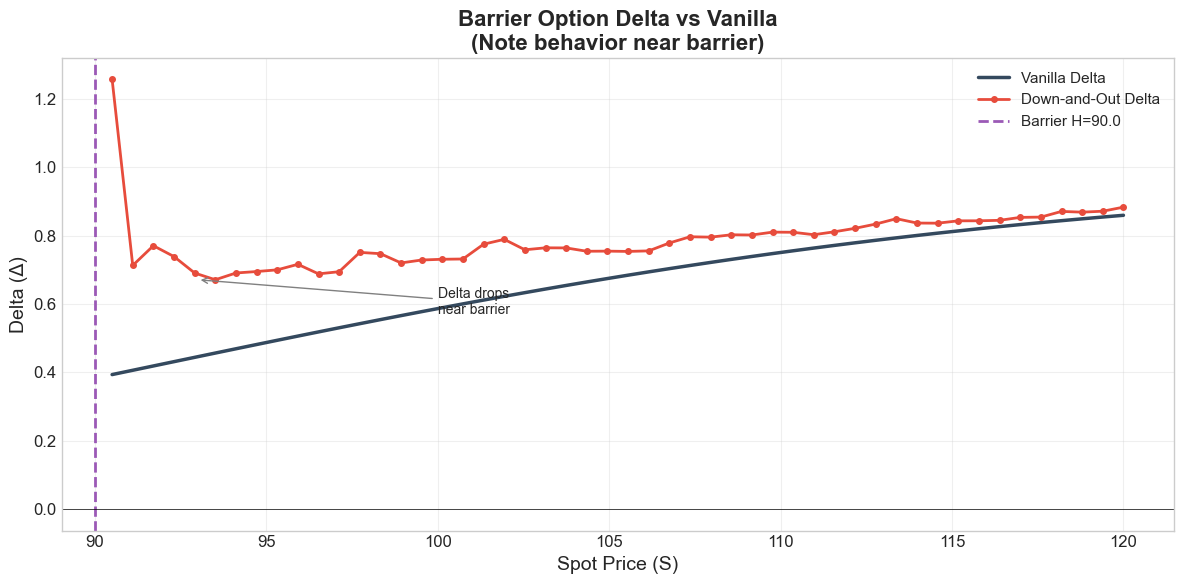

In [9]:
def plot_barrier_delta(save_fig: bool = False):
    """
    Plot delta for barrier options vs vanilla, showing discontinuity near barrier.
    """
    K = BASE_PARAMS['K']
    H = BASE_PARAMS['H']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(H + 0.5, 120, 50)
    epsilon = 0.5
    
    # Vanilla delta
    vanilla_deltas = []
    for S in spots:
        V_up = bs_call(S + epsilon, K, T, r, q, sigma)
        V_down = bs_call(S - epsilon, K, T, r, q, sigma)
        vanilla_deltas.append((V_up - V_down) / (2 * epsilon))
    
    # Barrier delta (via MC bump-and-reprice)
    print("Computing barrier deltas (this may take a moment)...")
    ko_deltas = []
    for S in spots:
        V_up, _, _, _ = barrier_mc(S + epsilon, K, H, T, r, q, sigma, n_paths=30000,
                                   barrier_type='down', knock_type='out')
        V_down, _, _, _ = barrier_mc(S - epsilon, K, H, T, r, q, sigma, n_paths=30000,
                                     barrier_type='down', knock_type='out')
        ko_deltas.append((V_up - V_down) / (2 * epsilon))
    print("Done!")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(spots, vanilla_deltas, color=COLORS['vanilla'], linewidth=2.5, label='Vanilla Delta')
    ax.plot(spots, ko_deltas, 'o-', color=COLORS['knock_out'], linewidth=2, 
            markersize=4, label='Down-and-Out Delta')
    ax.axvline(x=H, color=COLORS['barrier'], linewidth=2, linestyle='--', label=f'Barrier H={H}')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Delta (Δ)')
    ax.set_title('Barrier Option Delta vs Vanilla\n(Note behavior near barrier)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Annotation
    ax.annotate('Delta drops\nnear barrier', xy=(H+3, ko_deltas[5]), xytext=(H+10, ko_deltas[5]-0.1),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.tight_layout()
    if save_fig:
        plt.savefig('barrier_delta.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_barrier_delta(save_fig=SAVE_FIGURES)

## 6. Discrete vs Continuous Monitoring

Computing prices with different monitoring frequencies...
Done!


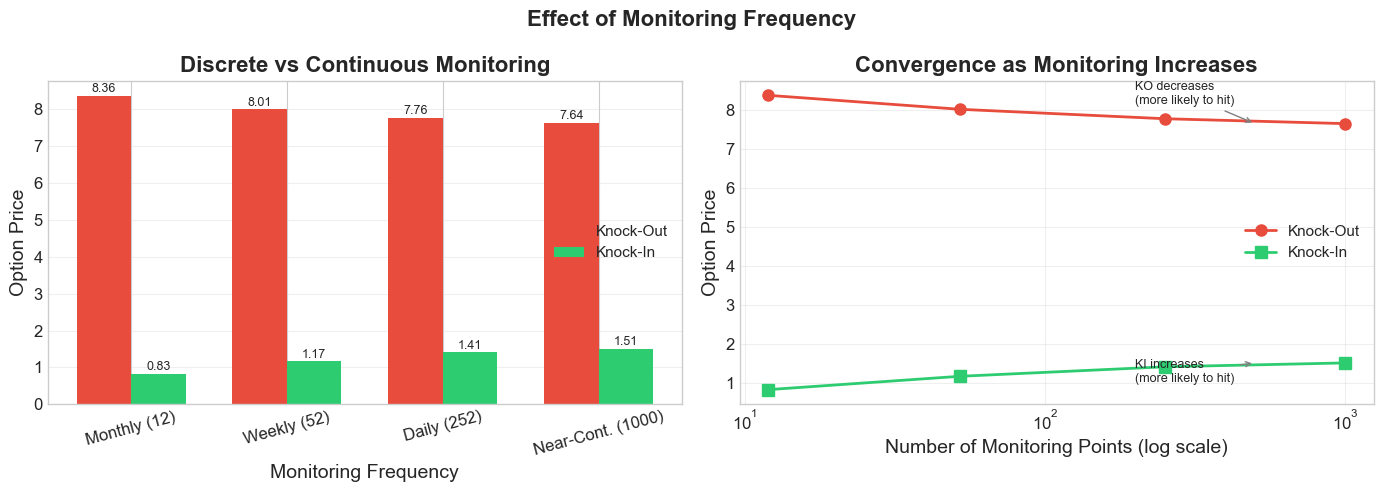

In [10]:
def plot_monitoring_effect(save_fig: bool = False):
    """
    Show how monitoring frequency affects barrier option prices.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    H = BASE_PARAMS['H']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Different monitoring frequencies
    n_steps_list = [12, 52, 252, 1000]  # Monthly, weekly, daily, high-freq
    labels = ['Monthly (12)', 'Weekly (52)', 'Daily (252)', 'Near-Cont. (1000)']
    
    ko_prices = []
    ki_prices = []
    
    print("Computing prices with different monitoring frequencies...")
    for n_steps in n_steps_list:
        ko_price, _, _, _ = barrier_mc(S0, K, H, T, r, q, sigma, n_paths=100000, 
                                       n_steps=n_steps, barrier_type='down', knock_type='out')
        ki_price, _, _, _ = barrier_mc(S0, K, H, T, r, q, sigma, n_paths=100000, 
                                       n_steps=n_steps, barrier_type='down', knock_type='in')
        ko_prices.append(ko_price)
        ki_prices.append(ki_price)
    print("Done!")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.arange(len(labels))
    width = 0.35
    
    # Bar chart
    ax = axes[0]
    bars1 = ax.bar(x - width/2, ko_prices, width, color=COLORS['knock_out'], label='Knock-Out')
    bars2 = ax.bar(x + width/2, ki_prices, width, color=COLORS['knock_in'], label='Knock-In')
    ax.set_xlabel('Monitoring Frequency')
    ax.set_ylabel('Option Price')
    ax.set_title('Discrete vs Continuous Monitoring', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{bar.get_height():.2f}', ha='center', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{bar.get_height():.2f}', ha='center', fontsize=9)
    
    # Convergence plot
    ax = axes[1]
    ax.plot(n_steps_list, ko_prices, 'o-', color=COLORS['knock_out'], linewidth=2, 
            markersize=8, label='Knock-Out')
    ax.plot(n_steps_list, ki_prices, 's-', color=COLORS['knock_in'], linewidth=2, 
            markersize=8, label='Knock-In')
    ax.set_xscale('log')
    ax.set_xlabel('Number of Monitoring Points (log scale)')
    ax.set_ylabel('Option Price')
    ax.set_title('Convergence as Monitoring Increases', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add annotation
    ax.annotate('KO decreases\n(more likely to hit)', xy=(500, ko_prices[-1]), 
                xytext=(200, ko_prices[-1]+0.5), fontsize=9,
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.annotate('KI increases\n(more likely to hit)', xy=(500, ki_prices[-1]), 
                xytext=(200, ki_prices[-1]-0.5), fontsize=9,
                arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.suptitle('Effect of Monitoring Frequency', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('barrier_monitoring_effect.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_monitoring_effect(save_fig=SAVE_FIGURES)

## 7. Sample Paths Visualization

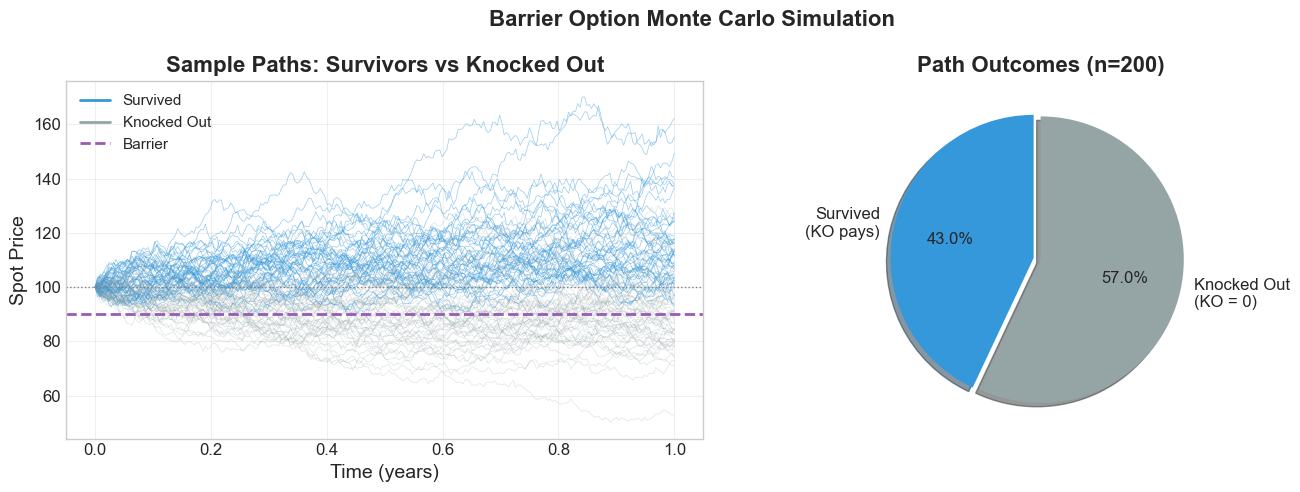

In [11]:
def plot_sample_paths_barrier(save_fig: bool = False):
    """
    Visualize sample paths showing which survive vs which get knocked out.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    H = BASE_PARAMS['H']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Generate paths
    _, _, paths, hit_barrier = barrier_mc(S0, K, H, T, r, q, sigma, n_paths=200, n_steps=252,
                                          barrier_type='down', knock_type='out', seed=42)
    
    times = np.linspace(0, T, paths.shape[1])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # All paths colored by outcome
    ax = axes[0]
    for i in range(min(100, paths.shape[0])):
        if hit_barrier[i]:
            ax.plot(times, paths[i, :], color=COLORS['path_dead'], alpha=0.3, linewidth=0.5)
        else:
            ax.plot(times, paths[i, :], color=COLORS['path_alive'], alpha=0.5, linewidth=0.5)
    
    ax.axhline(y=H, color=COLORS['barrier'], linewidth=2, linestyle='--', label=f'Barrier H={H}')
    ax.axhline(y=K, color='gray', linewidth=1, linestyle=':', label=f'Strike K={K}')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Spot Price')
    ax.set_title('Sample Paths: Survivors vs Knocked Out', fontweight='bold')
    
    # Custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=COLORS['path_alive'], linewidth=2, label='Survived'),
        Line2D([0], [0], color=COLORS['path_dead'], linewidth=2, label='Knocked Out'),
        Line2D([0], [0], color=COLORS['barrier'], linewidth=2, linestyle='--', label='Barrier'),
    ]
    ax.legend(handles=legend_elements)
    ax.grid(True, alpha=0.3)
    
    # Statistics
    ax = axes[1]
    n_total = len(hit_barrier)
    n_hit = np.sum(hit_barrier)
    n_survived = n_total - n_hit
    
    labels = ['Survived\n(KO pays)', 'Knocked Out\n(KO = 0)']
    sizes = [n_survived, n_hit]
    colors = [COLORS['path_alive'], COLORS['path_dead']]
    explode = (0.05, 0)
    
    ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
           shadow=True, startangle=90)
    ax.set_title(f'Path Outcomes (n={n_total})', fontweight='bold')
    
    plt.suptitle('Barrier Option Monte Carlo Simulation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('barrier_sample_paths.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_paths_barrier(save_fig=SAVE_FIGURES)

## Summary Statistics

In [12]:
def print_summary_statistics():
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    H = BASE_PARAMS['H']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Prices
    vanilla = bs_call(S0, K, T, r, q, sigma)
    do_call, do_se, _, hit = barrier_mc(S0, K, H, T, r, q, sigma, n_paths=200000,
                                        barrier_type='down', knock_type='out')
    di_call = vanilla - do_call  # Using parity
    
    print("=" * 70)
    print("BARRIER OPTIONS: COMPREHENSIVE SUMMARY")
    print("=" * 70)
    print(f"\nParameters: S₀={S0}, K={K}, H={H}, T={T}")
    print(f"           r={r*100:.1f}%, q={q*100:.1f}%, σ={sigma*100:.0f}%")
    
    print("\n" + "-" * 70)
    print("OPTION PRICES")
    print("-" * 70)
    print(f"{'Vanilla Call (BSM)':<30} {vanilla:>15.4f}")
    print(f"{'Down-and-Out Call (MC)':<30} {do_call:>15.4f}")
    print(f"{'Down-and-In Call (Parity)':<30} {di_call:>15.4f}")
    
    print("\n" + "-" * 70)
    print("DISCOUNT FROM VANILLA")
    print("-" * 70)
    print(f"KO Discount: {(1 - do_call/vanilla)*100:.1f}% cheaper than vanilla")
    print(f"KI Discount: {(1 - di_call/vanilla)*100:.1f}% cheaper than vanilla")
    
    print("\n" + "-" * 70)
    print("BARRIER HIT PROBABILITY")
    print("-" * 70)
    hit_prob = np.mean(hit)
    print(f"P(Hit Barrier) ≈ {hit_prob*100:.1f}%")
    print(f"P(Survive) ≈ {(1-hit_prob)*100:.1f}%")
    
    print("\n" + "-" * 70)
    print("KEY INSIGHTS")
    print("-" * 70)
    print("1. In-Out Parity: KI + KO = Vanilla")
    print("2. Barrier options are ALWAYS cheaper than vanilla")
    print("3. Closer barrier → cheaper KO, more expensive KI")
    print("4. More monitoring → lower KO price (more likely to hit)")
    print("5. Greeks are discontinuous at the barrier")
    print("=" * 70)

print_summary_statistics()

BARRIER OPTIONS: COMPREHENSIVE SUMMARY

Parameters: S₀=100.0, K=100.0, H=90.0, T=1.0
           r=5.0%, q=2.0%, σ=20%

----------------------------------------------------------------------
OPTION PRICES
----------------------------------------------------------------------
Vanilla Call (BSM)                      9.2270
Down-and-Out Call (MC)                  7.7589
Down-and-In Call (Parity)               1.4681

----------------------------------------------------------------------
DISCOUNT FROM VANILLA
----------------------------------------------------------------------
KO Discount: 15.9% cheaper than vanilla
KI Discount: 84.1% cheaper than vanilla

----------------------------------------------------------------------
BARRIER HIT PROBABILITY
----------------------------------------------------------------------
P(Hit Barrier) ≈ 55.8%
P(Survive) ≈ 44.2%

----------------------------------------------------------------------
KEY INSIGHTS
---------------------------------------------